<a href="https://colab.research.google.com/github/pathbit/pathbit-academy-ai/blob/master/0001_llm_x_lrm/notebooks/comparacao_llm_lrm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

> Modo opcional `LAB_PROVIDER=ollama`: executa a infraestrutura com Qwen local. Não comprova desempenho de Groq nem comportamento de um LRM. Sem essa variável, as chamadas cloud exigem `GROQ_API_KEY`.


# ✨ **Pathbit Academy AI**
---

🚨 **IMPORTANTE:**

*💥 QUALQUER PESSOA QUE CONSIGA RESOLVER A EQUAÇÃO `2 + 2 = ?` PODE CONTINUAR OS PASSOS ABAIXO*

**Artigo de referência:** [https://github.com/pathbit/pathbit-academy-ai/blob/master/0001_llm_x_lrm/article/ARTICLE.md](https://github.com/pathbit/pathbit-academy-ai/blob/master/0001_llm_x_lrm/article/ARTICLE.md)

### ֎ **Comparação LLM vs LRM**
---

#### ⁉️ O que é LLM de forma prática?

**Foco:** geração de linguagem natural.
Treinamento: enormes volumes de texto para aprender padrões linguísticos.

**Ponto forte:** velocidade e flexibilidade para responder qualquer tipo de pergunta textual.

**Ponto fraco:** raciocínio profundo e consistência em decisões complexas.


#### ⁉️ O que é LRM de forma prática?

**Foco:** raciocínio estruturado e resolução de problemas.
Treinamento: combina dados textuais com técnicas que forçam o modelo a explicar e validar seu raciocínio (cadeia de pensamento, decomposição de problemas, verificação de hipóteses).

**Ponto forte:** consistência em tomadas de decisão complexas.

**Ponto fraco:** pode ser mais lento e caro que um LLM para tarefas simples.

#### ⛳ Criação de conta no Groq
---

##### ▶ Acessar o site abaixo para criar sua conta

**[Groq.com](https://console.groq.com/)**

##### ▶ Criar uma `API KEY` para a sua conta

![Criação API KEY](https://raw.githubusercontent.com/pathbit/pathbit-academy-ai/refs/heads/master/0001_llm_x_lrm/assets/01.png)

##### ▶ Copiar e salvar a Api Key em um lugar seguro

> **Observações**: *Você pode acessar Api Keys criados através deste link: [https://console.groq.com/keys](https://console.groq.com/keys)*

![Copiar API KEY](https://raw.githubusercontent.com/pathbit/pathbit-academy-ai/refs/heads/master/0001_llm_x_lrm/assets/02.png)

##### ▶ Adicionar a Api Key criada nas `secrets` do seu Notebook

![Adicionar API KEY no Secrets](https://raw.githubusercontent.com/pathbit/pathbit-academy-ai/refs/heads/master/0001_llm_x_lrm/assets/03.png)


![Adicionar API KEY no Secrets](https://raw.githubusercontent.com/pathbit/pathbit-academy-ai/refs/heads/master/0001_llm_x_lrm/assets/04.png)

#### ⚙️ Configuração do ambiente
---

##### ▶ Correção automática para Google Colab

🚨 **IMPORTANTE:** Se você estiver executando no Google Colab, esta célula corrige automaticamente problemas de compatibilidade do `tqdm`.


In [1]:
# 🔧 CORREÇÃO AUTOMÁTICA PARA GOOGLE COLAB
# ==========================================
# Esta célula resolve automaticamente conflitos de dependências do tqdm

# Detectar se estamos no Google Colab
try:
    import google.colab
    IN_COLAB = True
    print("🌐 Detectado: Google Colab")
    print("🔧 Aplicando correção para conflito de tqdm...")
    
    # CORREÇÃO: Atualizar tqdm para resolver conflitos de dependências
    get_ipython().run_line_magic('pip', 'install --upgrade tqdm>=4.67 --force-reinstall --quiet')
    print("✅ tqdm atualizado com sucesso!")
    print("📦 Versão do tqdm corrigida para resolver conflitos com datasets e dataproc-spark-connect")
    
except ImportError:
    IN_COLAB = False
    print("💻 Detectado: Ambiente Local")
    print("ℹ️  Correção do tqdm não necessária no ambiente local")

print("\n🎯 Ambiente configurado! Continue com a próxima célula.")


💻 Detectado: Ambiente Local
ℹ️  Correção do tqdm não necessária no ambiente local

🎯 Ambiente configurado! Continue com a próxima célula.


##### ▶ Instalar os pacotes que iremos utilizar neste projeto

##### ▶ Instalar dependências do projeto

📦 **Instalação das bibliotecas necessárias para o projeto.**


In [2]:
# 📦 INSTALAÇÃO DAS DEPENDÊNCIAS
# ===============================
# Instalação das bibliotecas necessárias para o projeto

# Verificar a versão do python
import sys
import os
import site

print("📊 Informações do ambiente:")
print("Caminho do Python:", sys.executable)
print("Versão do Python:", sys.version)
print("PATH:", os.environ.get('PATH', 'Não encontrado'))
print("Sites de pacotes:", site.getsitepackages())

# Instalar a biblioteca do groq
print("\n📦 Instalando dependências...")
if IN_COLAB:
    get_ipython().run_line_magic('pip', 'install -q groq')
else:
    try:
        import groq  # noqa: F401  (já instalado via requirements.txt)
        print("✅ groq já está instalado neste ambiente")
    except ImportError:
        import subprocess
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "groq"])

print("✅ Instalação concluída!")
print("🚀 Pronto para usar a API do Groq!")


📊 Informações do ambiente:
Caminho do Python: /Users/elielsousa/Projetos/pathbit/github/pathbit-academy-ai/.venv/bin/python
Versão do Python: 3.12.12 (main, Feb 23 2026, 22:43:49) [Clang 17.0.0 (clang-1700.6.3.2)]
PATH: /Users/elielsousa/bin:/Users/elielsousa/.codeium/windsurf/bin:/Users/elielsousa/.mavis/bin:/Users/elielsousa/.grok/bin:/Users/elielsousa/.local/bin:/Users/elielsousa/.antigravity-ide/antigravity-ide/bin:/Users/elielsousa/.kimi-code/bin:/Users/elielsousa/.bun/bin:/Users/elielsousa/.pyenv/shims:/Users/elielsousa/.nvm/versions/node/v22.22.0/bin:/Users/elielsousa/.antigravity/antigravity/bin:/usr/local/bin:/System/Cryptexes/App/usr/bin:/usr/bin:/bin:/usr/sbin:/sbin:/var/run/com.apple.security.cryptexd/codex.system/bootstrap/usr/local/bin:/var/run/com.apple.security.cryptexd/codex.system/bootstrap/usr/bin:/var/run/com.apple.security.cryptexd/codex.system/bootstrap/usr/appleinternal/bin:/pkg/env/global/bin:/Library/Apple/usr/bin:/usr/local/share/dotnet:~/.dotnet/tools:/opt/ho

✅ groq já está instalado neste ambiente
✅ Instalação concluída!
🚀 Pronto para usar a API do Groq!


In [3]:
# 🔧 Correção automática para Google Colab
# ==========================================

# Detectar se estamos no Google Colab
try:
    import google.colab
    IN_COLAB = True
    print("🌐 Detectado: Google Colab")
    
    # 🔧 CORREÇÃO: Atualizar tqdm para resolver conflitos de dependências
    print("🔧 Aplicando correção para conflito de tqdm...")
    %pip install --upgrade tqdm>=4.67 --force-reinstall --quiet
    print("✅ tqdm atualizado com sucesso!")
    
except ImportError:
    IN_COLAB = False
    print("💻 Detectado: Ambiente Local")

# Verificar a versão do python
import sys
import os
import site

print("\n📊 Informações do ambiente:")
print("Caminho do Python:", sys.executable)
print("Versão do Python:", sys.version)
print("PATH:", os.environ.get('PATH', 'Não encontrado'))
print("Sites de pacotes:", site.getsitepackages())

# Instalar a biblioteca do groq
print("\n📦 Instalando dependências...")
try:
    import groq  # noqa: F401
    print("✅ groq já está instalado neste ambiente")
except ImportError:
    %pip install -q groq

print("✅ Instalação concluída!")

💻 Detectado: Ambiente Local

📊 Informações do ambiente:
Caminho do Python: /Users/elielsousa/Projetos/pathbit/github/pathbit-academy-ai/.venv/bin/python
Versão do Python: 3.12.12 (main, Feb 23 2026, 22:43:49) [Clang 17.0.0 (clang-1700.6.3.2)]
PATH: /Users/elielsousa/bin:/Users/elielsousa/.codeium/windsurf/bin:/Users/elielsousa/.mavis/bin:/Users/elielsousa/.grok/bin:/Users/elielsousa/.local/bin:/Users/elielsousa/.antigravity-ide/antigravity-ide/bin:/Users/elielsousa/.kimi-code/bin:/Users/elielsousa/.bun/bin:/Users/elielsousa/.pyenv/shims:/Users/elielsousa/.nvm/versions/node/v22.22.0/bin:/Users/elielsousa/.antigravity/antigravity/bin:/usr/local/bin:/System/Cryptexes/App/usr/bin:/usr/bin:/bin:/usr/sbin:/sbin:/var/run/com.apple.security.cryptexd/codex.system/bootstrap/usr/local/bin:/var/run/com.apple.security.cryptexd/codex.system/bootstrap/usr/bin:/var/run/com.apple.security.cryptexd/codex.system/bootstrap/usr/appleinternal/bin:/pkg/env/global/bin:/Library/Apple/usr/bin:/usr/local/share/d

##### ▶ Criar e recuperar a variável de ambiente para utilizar no Groq

In [4]:
# 🚀 Configuração para execução local e Colab
# ============================================

# Adicionar o diretório src ao path para importar módulos locais
import sys
import os
sys.path.append('../src')

# Constante com o nome da secret adicionada no Notebook
GROQ_API_KEY_NAME = "GROQ_API_KEY"

# Importar configuração local
try:
    from config_local import configurar_api_key, exibir_markdown, exibir_resposta_formatada
    print("✅ Configuração local carregada")
except ImportError:
    print("⚠️  Executando em modo Colab")
    
    # Funções para Colab
    def configurar_api_key():
        from google.colab import userdata
        try:
            groq_api_key = userdata.get(GROQ_API_KEY_NAME)
            os.environ[GROQ_API_KEY_NAME] = groq_api_key
            print(f"✅ {GROQ_API_KEY_NAME}: {os.environ[GROQ_API_KEY_NAME][:6]}******")
            return True
        except Exception as e:
            print(f"❌ Erro ao configurar API Key: {e}")
            return False
    
    def exibir_markdown(texto):
        from IPython.display import Markdown, display
        display(Markdown(texto))
    
    def exibir_resposta_formatada(modelo, pergunta, resposta, raciocinio=None, tempo=0.0):
        from IPython.display import Markdown, display
        texto_raciocinio = ""
        if raciocinio:
            texto_raciocinio = f"""
        
## 🧐 Raciocínio
================================================

{raciocinio.strip()}
"""
        
        texto_md = f"""
## 🧠 Modelo: `{modelo}`
**⏱ Tempo de execução:** {tempo:.2f}s{texto_raciocinio}

### 📥 Pergunta

{pergunta.strip()}

### 📤 Resposta

{resposta.strip()}
        """
        
        exibir_markdown(texto_md)

# Configurar API Key
configurar_api_key()

✅ Configuração local carregada
Modo local explícito: Qwen 0.5B/1.5B, não um benchmark de LRM nem de Groq.


True

##### ▶ Validar se o Groq está funcionando corretamente

⚠️ **Atualização (out/2026):** os modelos usados na primeira versão deste notebook (`compound-beta`, `llama-3.3-70b-versatile` e `deepseek-r1-distill-llama-70b`) foram descontinuados pela Groq no plano gratuito/desenvolvedor ([página de deprecações](https://console.groq.com/docs/deprecations)). O teste rápido abaixo usa o `openai/gpt-oss-20b`, modelo de produção da Groq.

In [5]:
# Validar se o Groq está funcionando corretamente
# ------------------------------------------------------------------------------

# Importar os módulos
import os
from groq import Groq
from IPython.display import Markdown, display

# Configurar a API Key da Groq
# (recomendo guardar em segredos do Colab)
groq_api_key = os.getenv(GROQ_API_KEY_NAME, "")
from config_local import criar_cliente_groq as cliente_configurado
client = cliente_configurado()

# Definir o modelo de LLM que iremos utilizar
# Modelos: https://console.groq.com/docs/models
LLM_MODEL = "openai/gpt-oss-20b"

# Criar a prompt do sistema
prompt_sistema = """
REGRAS:

++++

Você é um especialista da área de inteligência artificial e está instruindo
crianças e adolescentes no período escolar fundamental.

  1. Utilize respostas fáceis para o seu público.

  2. Utilize exemplos práticos do dia-a-dia desse público.

  3. A resposta deve ser formatada no padrão Markdown, seus títulos devem começar
  com 3 "#", utilizar emojis e ter as quebras adequadas para separar bem cada
  parte do texto, facilitando a leitura.

  4. Você pode utilizar um pouco de linguagem técnica até para que a pessoa tenha
  interesse em continuar pesquisando sobre o tema e seus subtemas.

++++

""".strip()

# Pergunta do usuário
pergunta_usuario = "Qual a diferença entre LLMs e LRMs?"

# Criar o prompt final concatenado (para exibir ou logar)
prompt_final = f"{prompt_sistema}\n\nUSUÁRIO:\n\n{pergunta_usuario}"

# Montar mensagens no formato da Groq e chamar o modelo
messages = [
    {"role": "system", "content": prompt_sistema},
    {"role": "user", "content": pergunta_usuario},
]

resp = client.chat.completions.create(
    model=LLM_MODEL,
    messages=messages,
    temperature=0.3,
    max_completion_tokens=2048,
    reasoning_effort="low",  # GPT-OSS sempre raciocina; 'low' deixa a resposta direta
    include_reasoning=False,
)

resposta_modelo = resp.choices[0].message.content

# Visualizando o resultado formatado em Markdown
display(Markdown(f"""
## > Prompt do sistema
{prompt_sistema}

## > Pergunta do usuário
{pergunta_usuario}

## > Prompt final enviado ao LLM
{prompt_final}

## > Resposta do LLM
{resposta_modelo}
"""))


## > Prompt do sistema
REGRAS:

++++

Você é um especialista da área de inteligência artificial e está instruindo
crianças e adolescentes no período escolar fundamental.

  1. Utilize respostas fáceis para o seu público.

  2. Utilize exemplos práticos do dia-a-dia desse público.

  3. A resposta deve ser formatada no padrão Markdown, seus títulos devem começar
  com 3 "#", utilizar emojis e ter as quebras adequadas para separar bem cada
  parte do texto, facilitando a leitura.

  4. Você pode utilizar um pouco de linguagem técnica até para que a pessoa tenha
  interesse em continuar pesquisando sobre o tema e seus subtemas.

++++

## > Pergunta do usuário
Qual a diferença entre LLMs e LRMs?

## > Prompt final enviado ao LLM
REGRAS:

++++

Você é um especialista da área de inteligência artificial e está instruindo
crianças e adolescentes no período escolar fundamental.

  1. Utilize respostas fáceis para o seu público.

  2. Utilize exemplos práticos do dia-a-dia desse público.

  3. A resposta deve ser formatada no padrão Markdown, seus títulos devem começar
  com 3 "#", utilizar emojis e ter as quebras adequadas para separar bem cada
  parte do texto, facilitando a leitura.

  4. Você pode utilizar um pouco de linguagem técnica até para que a pessoa tenha
  interesse em continuar pesquisando sobre o tema e seus subtemas.

++++

USUÁRIO:

Qual a diferença entre LLMs e LRMs?

## > Resposta do LLM
LLMs (Linguagem Léxica Machine) e LRMs (Linguagem Regressiva Machine) são dois tipos de modelos de aprendizado de máquina que usam diferentes algoritmos para processar e interpretar dados. A diferença principais entre eles é que LLMs são baseados em linguagens lógicas, enquanto LRMs são baseados em linguagens regressivas.

LLMs usam algoritmos de aprendizado de máquina que buscam prever o próximo valor de uma sequência de dados, geralmente usando algoritmos de aprendizado de máquina como o algoritmo de aprend


### </> Criando as funções para utilizar modelos de LLM e LRM
---

**ℹ️️ Observações:**

*Tentei fazer a melhor documentação possível para explicar o código.*

**⚠️ Importante:**

*Para garantir os melhores resultados, o código utiliza dois modelos de linguagem diferentes, cada um com uma finalidade específica:*

- **Papel LLM → `openai/gpt-oss-20b` com `reasoning_effort="low"`:** modelo menor e rápido, usado aqui para resposta direta (resumo, reescrita, conversa). Com esforço de raciocínio baixo ele gasta poucos tokens pensando e não devolvemos a cadeia de raciocínio.

- **Papel LRM → `openai/gpt-oss-120b` com `reasoning_effort="high"`:** modelo maior, usado para problemas que exigem pensar em etapas (lógica, trade-offs, planejamento). A cadeia de raciocínio volta separada em `message.reasoning` e aparece na seção **🧐 Raciocínio**.

> **Por que não os modelos originais?** A primeira versão usava `llama3-70b-8192`/`llama-3.3-70b-versatile` (LLM) e `deepseek-r1-distill-llama-70b` (LRM). A Groq descontinuou todos no plano gratuito/desenvolvedor (30/08/2025, 16/08/2026 e 02/10/2025, respectivamente) e recomenda o `openai/gpt-oss-120b` como substituto. Como hoje os modelos de produção da Groq são todos de raciocínio, o contraste LLM × LRM é feito pelo **orçamento de raciocínio**. Se quiser um LLM puro, o `qwen/qwen3.8-27b` (preview) aceita `reasoning_effort="none"`.
>
> As saídas salvas abaixo foram geradas com os modelos originais, antes da descontinuação; ao executar de novo, você verá as respostas dos modelos atuais.

> **FUNÇÕES BÁSICAS**


**1. Função para recuperar o cliente do Groq**


In [6]:
# Definições das funções auxiliares
# ------------------------------------------------------------------------------

# Importar os módulos
import os
import time
from groq import Groq
from typing import Tuple, Optional
from IPython.display import Markdown, display


def criar_cliente_groq() -> Groq:
    """
    Cria o cliente da Groq usando a variável de ambiente GROQ_API_KEY.

    Por que usar env var?
    - Segurança: evita hardcode de chaves no notebook.
    - Reprodutibilidade: o mesmo código funciona em diferentes ambientes.
    """
    groq_api_key = os.getenv(GROQ_API_KEY_NAME, "")
    if not groq_api_key and os.getenv("LAB_PROVIDER") != "ollama":
        raise RuntimeError(
            "GROQ_API_KEY não definida. No Colab, use: os.environ['GROQ_API_KEY']='sua_chave'"
        )
    return cliente_configurado()


def exibir_resposta(
    modelo: str,
    pergunta: str,
    resposta: str,
    raciocinio: str = None,
    tempo: float = 0.0
  ):
    """
    Exibe saída formatada em Markdown no Jupyter/Colab.
    - modelo     : nome do modelo utilizado (LLM ou LRM)
    - pergunta   : texto enviado
    - resposta   : resposta final ao usuário
    - raciocinio : cadeia de raciocínio (opcional)
    - tempo      : tempo total da execução
    """
    if os.getenv("LAB_PROVIDER") == "ollama":
        modelo = "qwen2.5:1.5b (baseline local, não LRM)" if "120b" in modelo else "qwen2.5:0.5b (baseline local)"
    texto_raciocinio = ""

    if raciocinio:
        texto_raciocinio += f"\n\n"
        texto_raciocinio += f"## 🧐 Raciocínio                                \n"
        texto_raciocinio += f"================================================\n\n"
        texto_raciocinio += f"{raciocinio.strip()}"

    texto_md = f"""
## 🧠 Modelo: `{modelo}`
**⏱ Tempo de execução:** {tempo:.2f}s

{texto_raciocinio}

### 📥 Pergunta

{pergunta.strip()}

### 📤 Resposta

{resposta.strip()}
    """

    display(Markdown(texto_md))

> **LLM: FUNÇÕES E TESTES**



**2. LLM: Função para responder usando modelo GPT-OSS 20B (raciocínio baixo) do Groq**

In [7]:
# Definição da função para responder a pergunta usando LLM
# ------------------------------------------------------------------------------

# Importar os módulos
import os
import time
from typing import Tuple, Optional
from groq import Groq

# ==============================
# Função: perguntar_llm
# Objetivo: enviar pergunta a um modelo de LINGUAGEM (LLM)
# Retorna: (texto_resposta, tempo_em_segundos)
# ==============================
def perguntar_llm(
    pergunta: str,
    modelo: str = "openai/gpt-oss-20b",     # Modelo rápido no papel de LLM
    temperatura: float = 0.2,                # Controla a aleatoriedade da resposta
    max_tokens_resposta: int = 1024,         # Limita tamanho da resposta (custo/latência)
    sistema: Optional[str] = None,           # Regras ou persona opcionais
    esforco_raciocinio: str = "low",         # GPT-OSS: 'low' = resposta direta
    folga_raciocinio: int = 1024             # Tokens extras para o raciocínio interno
) -> Tuple[str, str, float]:
    """
    Envia uma pergunta para um modelo LLM.

    Parâmetros:
    - pergunta           : texto enviado ao modelo.
    - modelo             : modelo LLM para tarefas gerais (resumo, reescrita, Q&A).
    - temperatura        : controla a "criatividade" (0.1–0.3 = mais determinístico).
    - max_tokens_resposta: limita tamanho da saída, evitando custo ou lentidão.
    - sistema            : mensagem opcional para regras ou persona.

    Retorna:
    - modelo: nome do modelo usado.
    - texto: resposta final do modelo.
    - tempo: tempo total da chamada em segundos.

    Observação: nos modelos GPT-OSS o `max_completion_tokens` inclui os tokens de
    raciocínio, por isso somamos uma folga ao limite da resposta.
    """
    # cria o cliente autenticado
    cliente = criar_cliente_groq()

    # monta mensagens no formato da API (sistema opcional + usuário obrigatório)
    mensagens = []
    if sistema:
        mensagens.append({"role": "system", "content": sistema})

    mensagens.append({"role": "user", "content": pergunta})

    # marca início para medir tempo de execução
    inicio = time.perf_counter()

    # chamada à API da Groq
    resposta = cliente.chat.completions.create(
        model=modelo,
        messages=mensagens,
        temperature=temperatura,
        max_completion_tokens=max_tokens_resposta + folga_raciocinio,
        reasoning_effort=esforco_raciocinio,
        include_reasoning=False,             # papel LLM: só a resposta final
    )

    # calcula tempo total
    tempo_execucao = time.perf_counter() - inicio

    # extrai conteúdo textual da resposta
    texto_resposta = (resposta.choices[0].message.content or "").strip()

    return modelo, texto_resposta, tempo_execucao

**3. LLM: Testando a função para responder com LLM**

In [8]:
# Teste da função para responder a pergunta usando LLM
# ------------------------------------------------------------------------------

# Importar os módulos
import os
import time
from typing import Tuple, Optional
from groq import Groq

# LLM: resumo e reescrita de tom (usando perguntar_llm)
texto = """
O Banco Central manteve a taxa Selic inalterada. Analistas projetam estabilidade
nos próximos meses, com atenção à inflação de serviços e ao mercado de trabalho.
"""

# Pedimos um RESUMO curto (linguagem neutra) — tarefa típica de LLM
prompt_resumo = f"Resuma em 2 frases, com linguagem neutra e direta: {texto}"
modelo_resumo, resposta_resumo, tempo_resumo = perguntar_llm(
    pergunta=prompt_resumo,
    sistema="Responda em Markdown de forma clara e concisa."
)

exibir_resposta(
    modelo=modelo_resumo,
    pergunta=prompt_resumo,
    resposta=resposta_resumo,
    tempo=tempo_resumo
)

# Agora pedimos para REESCREVER o próprio resumo com outro tom.
#   - IMPORTANTE: incluímos explicitamente o 'resumo' no prompt (o modelo não “lembra” sozinho).
prompt_tom = (
    "Reescreva o resumo abaixo com tom mais informal e amigável, mantendo precisão.\n\n"
    f"RESUMO ORIGINAL:\n{resposta_resumo}"
)
modelo_tom, resposta_tom, tempo_tom = perguntar_llm(
    pergunta=prompt_tom,
    sistema="Responda em Markdown e use linguagem acessível; evite jargões."
)

exibir_resposta(
    modelo=modelo_tom,
    pergunta=prompt_tom,
    resposta=resposta_tom,
    tempo=tempo_tom
)


## 🧠 Modelo: `qwen2.5:0.5b (baseline local)`
**⏱ Tempo de execução:** 0.57s



### 📥 Pergunta

Resuma em 2 frases, com linguagem neutra e direta: 
O Banco Central manteve a taxa Selic inalterada. Analistas projetam estabilidade
nos próximos meses, com atenção à inflação de serviços e ao mercado de trabalho.

### 📤 Resposta

O Banco Central mantém a taxa Selic em estática, com foco na inflação de serviços e mercado de trabalho.
    


## 🧠 Modelo: `qwen2.5:0.5b (baseline local)`
**⏱ Tempo de execução:** 0.59s



### 📥 Pergunta

Reescreva o resumo abaixo com tom mais informal e amigável, mantendo precisão.

RESUMO ORIGINAL:
O Banco Central mantém a taxa Selic em estática, com foco na inflação de serviços e mercado de trabalho.

### 📤 Resposta

RESUMO: O Banco Central mantém a taxa Selic em estática, focando na inflação de serviços e mercado de trabalho.
    

> **LRM: FUNÇÕES E TESTES**

**4. LRM: Função para responder usando modelo GPT-OSS 120B (raciocínio alto) do Groq**

In [9]:
# Definição da função para responder a pergunta usando LRM
# ------------------------------------------------------------------------------

# Importar os módulos
import os
import time
from typing import Tuple, Optional
from groq import Groq

# ==============================
# Função: perguntar_lrm
# Objetivo: enviar pergunta a um modelo de RACIOCÍNIO (LRM)
# Retorna: (texto_ao_usuario, cadeia_de_raciocinio, tempo_em_segundos)
# ==============================
def perguntar_lrm(
    pergunta: str,
    modelo: str = "openai/gpt-oss-120b",             # Modelo de raciocínio (papel LRM)
    temperatura: float = 0.2,                        # Baixa variação para consistência
    formato_raciocinio: Optional[str] = "parsed",    # 'parsed', 'raw', 'hidden' ou None
    incluir_raciocinio: bool = True,                 # Só usado se formato_raciocinio=None
    max_tokens_resposta: int = 2000,                 # Limite da resposta final
    max_tokens_raciocinio: Optional[int] = None,     # Limite da cadeia de raciocínio
    sistema: Optional[str] = None,                   # Mensagem de sistema opcional
    esforco_raciocinio: str = "high",                # GPT-OSS: 'low' | 'medium' | 'high'
    folga_raciocinio: int = 6144                     # Tokens extras para a cadeia de raciocínio
) -> Tuple[str, str, Optional[str], float]:
    """
    Envia uma pergunta a um modelo de raciocínio (LRM) da Groq.

    Comportamento:
    - Se `formato_raciocinio` ∈ {'parsed','raw','hidden'} → usa `reasoning_format` e
      **NÃO** envia `include_reasoning` (evita erro 400).
      • 'parsed'  → cadeia vem separada em `message.reasoning`
      • 'raw'     → cadeia vem crua, com marcações
      • 'hidden'  → o modelo raciocina, mas não retorna a cadeia
    - Se `formato_raciocinio` for None → não envia `reasoning_format` e usa `include_reasoning`.

    Retorno:
      (modelo, conteudo_final, cadeia_de_raciocinio|None, tempo_execucao_s)

    Observação: nos modelos GPT-OSS o `max_completion_tokens` inclui os tokens de
    raciocínio; sem a folga, um esforço alto pode consumir todo o limite e a
    resposta final volta vazia.
    """
    # Cliente autenticado
    chave = os.getenv("GROQ_API_KEY")
    if not chave and os.getenv("LAB_PROVIDER") != "ollama":
        raise RuntimeError("Defina GROQ_API_KEY no ambiente.")
    cliente = cliente_configurado()

    # Mensagens no formato Chat
    mensagens = []
    if sistema:
        mensagens.append({"role": "system", "content": sistema})
    mensagens.append({"role": "user", "content": pergunta})

    # Monta kwargs dinâmicos conforme as regras da API
    kwargs = {
        "model": modelo,
        "messages": mensagens,
        "temperature": temperatura,
        "max_completion_tokens": max_tokens_resposta + folga_raciocinio,
        "reasoning_effort": esforco_raciocinio,
    }

    # Se limite de tokens do raciocínio foi definido, adiciona
    if max_tokens_raciocinio is not None:
        kwargs["max_reasoning_tokens"] = max_tokens_raciocinio

    # Regra de exclusão mútua:
    # - Se formato_raciocinio estiver definido, usa reasoning_format e IGNORA include_reasoning
    # - Se formato_raciocinio for None, usa include_reasoning (sem reasoning_format)
    if formato_raciocinio is not None:
        kwargs["reasoning_format"] = formato_raciocinio
        # NÃO adicionar include_reasoning para evitar o erro 400
    else:
        kwargs["include_reasoning"] = bool(incluir_raciocinio)

    # Chamada e cronômetro
    inicio = time.perf_counter()
    resp = cliente.chat.completions.create(**kwargs)
    tempo = time.perf_counter() - inicio

    # Extração da resposta e (se houver) do raciocínio
    msg = resp.choices[0].message
    conteudo = (msg.content or "").strip()

    # A cadeia só vem quando:
    # - usamos reasoning_format ('parsed'/'raw'), E
    # - não é 'hidden'
    if formato_raciocinio in ("parsed", "raw"):
        raciocinio = getattr(msg, "reasoning", None)
    else:
        # Quando formato=None e include_reasoning=True, algumas combinações
        # podem retornar o raciocínio embutido; a API nem sempre expõe em `reasoning`.
        raciocinio = getattr(msg, "reasoning", None)

    return modelo, conteudo, raciocinio, tempo

**5. LRM: Testando a função para responder com LRM**

-

**ℹ️️ IMPORTANTE:**

> *Para ver como o modelo chegou à resposta final, procure a seção **🧐 Raciocínio.** Essa é uma demonstração do poder dos modelos especializados em lógica e raciocínio.*


In [10]:
# Testando a função para responder a pergunta usando LRM
# ------------------------------------------------------------------------------

# Importar os módulos
import os
import time
import json
from typing import Tuple, Optional
from groq import Groq

cenario = {
    "perfil": "conservador",
    "inflacao_projetada_aa": 4.0,
    "cdi_aa": 13.25,
    "vencimentos_anos": [2026, 2027],
    "objetivo": "renda previsível com baixa volatilidade",
}
cenario_fmt = json.dumps(cenario, ensure_ascii=False)

prompt_lrm = f"""
Você é um analista de investimentos.

Dado o cenário:
- {cenario_fmt}

Decida entre:
- título atrelado ao CDI;
- prefixado curto;
- IPCA+ longo.

Importante:

1. Resposta e raciocínio sempre em português do brasil.
2. Estruture o raciocínio em etapas (riscos, liquidez, duration, sensibilidade à inflação).
3. Apresente a recomendação final e uma política de rebalanceamento simples.
4. Use números aproximados e justificativas claras.
"""

modelo, resposta, cadeia, tempo = perguntar_lrm(
    pergunta=prompt_lrm,
    sistema="Responda em Markdown, com listas numeradas nas etapas."
)

exibir_resposta(
    modelo=modelo,
    pergunta=prompt_lrm,
    resposta=resposta,
    raciocinio=cadeia,
    tempo=tempo
)


## 🧠 Modelo: `qwen2.5:1.5b (baseline local, não LRM)`
**⏱ Tempo de execução:** 3.88s



### 📥 Pergunta

Você é um analista de investimentos.

Dado o cenário:
- {"perfil": "conservador", "inflacao_projetada_aa": 4.0, "cdi_aa": 13.25, "vencimentos_anos": [2026, 2027], "objetivo": "renda previsível com baixa volatilidade"}

Decida entre:
- título atrelado ao CDI;
- prefixado curto;
- IPCA+ longo.

Importante:

1. Resposta e raciocínio sempre em português do brasil.
2. Estruture o raciocínio em etapas (riscos, liquidez, duration, sensibilidade à inflação).
3. Apresente a recomendação final e uma política de rebalanceamento simples.
4. Use números aproximados e justificativas claras.

### 📤 Resposta

### Etapa 1: Riscos

Primeiro, vamos analisar os riscos associados a cada opção:

- **Título atrelado ao CDI**: 
  - Risco: Risco do CDI, que é uma parte do risco do título atrelado. Isso inclui risco de crédito, risco de liquidez e risco de mercado.
  - Liquidez: CDI é uma opção de liquidez alta, mas não tão alta quanto a opção de longo prazo.
  - Duration: CDI tem uma duration mais cur
    

### Comparando ֎ LLM vs LRM 🧠
---

> *Agora, utilizando o problema anterior, vamos comparar a diferença entre os modelos com base em um mesmo contexto e/ou problema.*

#### CENÁRIO 1

In [11]:
# Comparação do MESMO PROMPT para LLM e LRM
# ------------------------------------------------------------------------------

# Importar os módulos
import os
import time
import json
from typing import Tuple, Optional
from groq import Groq
from IPython.display import Markdown, display

# Definindo o prompt
cenario = {
    "perfil": "conservador",
    "inflacao_projetada_aa": 5.0,
    "cdi_aa": 14.5,
    "vencimentos_anos": [2026, 2027],
    "objetivo": "renda previsível com baixa volatilidade",
}

cenario_fmt = json.dumps(cenario, ensure_ascii=False)

prompt = f"""
Você é um analista de investimentos.

Dado o cenário:
- {cenario_fmt}

Decida entre:
- título atrelado ao CDI;
- prefixado curto;
- IPCA+ longo.

Importante:

1. Resposta e raciocínio sempre em português do brasil.
2. Estruture o raciocínio em etapas (riscos, liquidez, duration, sensibilidade à inflação).
3. Apresente a recomendação final e uma política de rebalanceamento simples.
4. Use números aproximados e justificativas claras.
"""

# Título das comparações
display(Markdown("## 🔬 Comparação Lado a Lado — LLM vs LRM (MESMO prompt)"))
display(Markdown(f"### 📝 Prompt usado nos dois modelos\n> {prompt.replace('\\n', '\\n> ')}"))

# Máximo de tokens
total_tokens_resposta=2000

# LLM
modelo_llm, saida_llm, tempo_llm = perguntar_llm(
    pergunta=prompt,
    sistema="Responda em Markdown; explicite dependências, riscos e mitigação.",
    max_tokens_resposta=total_tokens_resposta
)

exibir_resposta(
    modelo=modelo_llm,
    pergunta=prompt,
    resposta=saida_llm,
    tempo=tempo_llm
)

# LRM
modelo_lrm, saida_lrm, cadeia_lrm, tempo_lrm = perguntar_lrm(
    pergunta=prompt,
    sistema="Responda em Markdown; explicite dependências, riscos e mitigação.",
    max_tokens_resposta=total_tokens_resposta
)

exibir_resposta(
    modelo=modelo_lrm,
    pergunta=prompt,
    resposta=saida_lrm,
    raciocinio=cadeia_lrm,
    tempo=tempo_lrm
)

## 🔬 Comparação Lado a Lado — LLM vs LRM (MESMO prompt)

### 📝 Prompt usado nos dois modelos
> 
Você é um analista de investimentos.

Dado o cenário:
- {"perfil": "conservador", "inflacao_projetada_aa": 5.0, "cdi_aa": 14.5, "vencimentos_anos": [2026, 2027], "objetivo": "renda previsível com baixa volatilidade"}

Decida entre:
- título atrelado ao CDI;
- prefixado curto;
- IPCA+ longo.

Importante:

1. Resposta e raciocínio sempre em português do brasil.
2. Estruture o raciocínio em etapas (riscos, liquidez, duration, sensibilidade à inflação).
3. Apresente a recomendação final e uma política de rebalanceamento simples.
4. Use números aproximados e justificativas claras.



## 🧠 Modelo: `qwen2.5:0.5b (baseline local)`
**⏱ Tempo de execução:** 3.15s



### 📥 Pergunta

Você é um analista de investimentos.

Dado o cenário:
- {"perfil": "conservador", "inflacao_projetada_aa": 5.0, "cdi_aa": 14.5, "vencimentos_anos": [2026, 2027], "objetivo": "renda previsível com baixa volatilidade"}

Decida entre:
- título atrelado ao CDI;
- prefixado curto;
- IPCA+ longo.

Importante:

1. Resposta e raciocínio sempre em português do brasil.
2. Estruture o raciocínio em etapas (riscos, liquidez, duration, sensibilidade à inflação).
3. Apresente a recomendação final e uma política de rebalanceamento simples.
4. Use números aproximados e justificativas claras.

### 📤 Resposta

# Resposta

### Etapas do Raciocínio

1. **Inflação Projetada AA (5.0%)**: A inflação projetada é considerada moderada, o que significa que a taxa de inflação é menor que a inflação média global (2.5% para o Brasil). Isso pode ser uma vantagem para o investidor, pois pode ser menos prejudicial para o rendimento.

2. **CDI AA (14.5%)**: O CDI AA é considerado alto, o que significa que a taxa de câmbio é alta e pode aument
    


## 🧠 Modelo: `qwen2.5:1.5b (baseline local, não LRM)`
**⏱ Tempo de execução:** 2.54s



### 📥 Pergunta

Você é um analista de investimentos.

Dado o cenário:
- {"perfil": "conservador", "inflacao_projetada_aa": 5.0, "cdi_aa": 14.5, "vencimentos_anos": [2026, 2027], "objetivo": "renda previsível com baixa volatilidade"}

Decida entre:
- título atrelado ao CDI;
- prefixado curto;
- IPCA+ longo.

Importante:

1. Resposta e raciocínio sempre em português do brasil.
2. Estruture o raciocínio em etapas (riscos, liquidez, duration, sensibilidade à inflação).
3. Apresente a recomendação final e uma política de rebalanceamento simples.
4. Use números aproximados e justificativas claras.

### 📤 Resposta

### Etapa 1: Definição do Título

**Riscos:**
- **Risco de volatilidade:** O título atrelado ao CDI é mais sensível à volatilidade do que os outros dois títulos.
- **Risco de inflação:** A inflação projetada é de 5%, o que pode levar ao reajuste do CDI.

**Liquidez:**
- **Título atrelado ao CDI:** Mais liquido do que os outros dois títulos.
- **Prefixado curto:** Mais liquido do que
    

#### CENÁRIO 2

In [12]:
# Comparação do MESMO PROMPT para LLM e LRM
# ------------------------------------------------------------------------------

# Importar os módulos
import os
import time
import json
from typing import Tuple, Optional
from groq import Groq
from IPython.display import Markdown, display

def _blockquote(txt: str) -> str:
    txt = (txt or "").strip()
    return "" if not txt else "\n".join("> " + ln for ln in txt.splitlines())

# Mesmo CENÁRIO (user prompt idêntico para ambos) ===
prompt_comum = """
Crie um plano de 6 semanas para lançar um MVP de assistente de atendimento:

  - Backend: APIs já existentes.
  - Frontend: web app simples.
  - Equipe: 2 devs full-stack, 1 QA, 1 PM; sprint semanal.
  - Restrições: integração com WhatsApp Business na semana 3+; testes de carga na semana 5.
  - Entregáveis por semana; riscos e mitigação; critérios de aceite.
""".strip()

display(Markdown("## 🔬 Comparação LLM vs LRM — **mesmo cenário**, papéis diferentes"))
display(Markdown("### 📝 Prompt (usuário) enviado *igual* aos dois modelos"))
display(Markdown(_blockquote(prompt_comum)))

# Máximo de tokens
total_tokens_resposta=2000

# Regras de SISTEMA para separar os perfis
prompt_sistema_comum =f"""
Você é um analista de projetos e deve EXPLICAR O RACIOCÍNIO.
-
Responda em Markdown, com:

  1) Decomposição em etapas (dependências, riscos, trade-offs).
  2) Estimativas simples (horas por papel, capacidade por sprint, margens).
  3) Tabela de riscos (probabilidade x impacto x mitigação) e caminho crítico.
  4) Critérios de aceite objetivos por semana.
  5) Formate como lista de semanas com checklist objetivo.

  Inclua uma seção final de 'Decisões e justificativas' com o porquê de cada escolha.

Importante:

  1. Texto do raciocínio sempre em português do brasil.
  2. Estruture o raciocínio em etapas (escopo, capacidade da equipe, dependências, riscos).
  3. Apresente o plano final e um ritual simples de replanejamento semanal.
  4. Use números aproximados e justificativas claras.
  5. Máximo de {total_tokens_resposta} tokens no retorno.
"""

# LLM: síntese direta, sem cadeia explícita ===
modelo_llm, saida_llm, tempo_llm = perguntar_llm(
    pergunta=prompt_comum,
    sistema=prompt_sistema_comum,
    max_tokens_resposta=8192
)

# Exibe resposta LLM
exibir_resposta(
    modelo=modelo_llm,
    pergunta=prompt_comum,
    resposta=saida_llm,
    tempo=tempo_llm
)

# -----

# LRM: estrutura com cadeia de raciocínio separada ===
modelo_lrm, saida_lrm, cadeia_lrm, tempo_lrm = perguntar_lrm(
    pergunta=prompt_comum,
    sistema=prompt_sistema_comum,
    max_tokens_resposta=2000
)

# Exibe LRM com raciocínio destacado
exibir_resposta(
    modelo=modelo_lrm,
    pergunta=prompt_comum,
    resposta=saida_lrm,
    raciocinio=cadeia_lrm,
    tempo=tempo_lrm
)

## 🔬 Comparação LLM vs LRM — **mesmo cenário**, papéis diferentes

### 📝 Prompt (usuário) enviado *igual* aos dois modelos

> Crie um plano de 6 semanas para lançar um MVP de assistente de atendimento:
> 
>   - Backend: APIs já existentes.
>   - Frontend: web app simples.
>   - Equipe: 2 devs full-stack, 1 QA, 1 PM; sprint semanal.
>   - Restrições: integração com WhatsApp Business na semana 3+; testes de carga na semana 5.
>   - Entregáveis por semana; riscos e mitigação; critérios de aceite.


## 🧠 Modelo: `qwen2.5:0.5b (baseline local)`
**⏱ Tempo de execução:** 2.86s



### 📥 Pergunta

Crie um plano de 6 semanas para lançar um MVP de assistente de atendimento:

  - Backend: APIs já existentes.
  - Frontend: web app simples.
  - Equipe: 2 devs full-stack, 1 QA, 1 PM; sprint semanal.
  - Restrições: integração com WhatsApp Business na semana 3+; testes de carga na semana 5.
  - Entregáveis por semana; riscos e mitigação; critérios de aceite.

### 📤 Resposta

| Etapa | Descrição | Riscos | Mitigação | Aceite |
| --- | --- | --- | --- | --- |
| 1 | Desenvolvimento do backend | Dependências: API existentes, integração com WhatsApp Business. | Nenhuma | Aceite |
| 2 | Desenvolvimento do frontend | Dependências: API existentes, integração com WhatsApp Business. | Nenhuma | Aceite |
| 3 | Integração com WhatsApp Business | Dependências: API existentes, integração com WhatsApp Business. | Nenhuma | Aceite |
|
    


## 🧠 Modelo: `qwen2.5:1.5b (baseline local, não LRM)`
**⏱ Tempo de execução:** 2.31s



### 📥 Pergunta

Crie um plano de 6 semanas para lançar um MVP de assistente de atendimento:

  - Backend: APIs já existentes.
  - Frontend: web app simples.
  - Equipe: 2 devs full-stack, 1 QA, 1 PM; sprint semanal.
  - Restrições: integração com WhatsApp Business na semana 3+; testes de carga na semana 5.
  - Entregáveis por semana; riscos e mitigação; critérios de aceite.

### 📤 Resposta

### Etapa 1: Planejamento inicial (Semana 1)
- **Escopo**: Criar MVP de assistente de atendimento.
- **Capacidade da equipe**: 2 devs full-stack, 1 QA, 1 PM.
- **Dependências**: 
  - Web app (frontend)
  - APIs (backend)
  - Integração com WhatsApp Business (semana 3+)
  - Testes de carga (semana 5)
- **Riscos e mitigação**:
  - **Dependências**: Integração com WhatsApp Business pode levar mais tempo
    

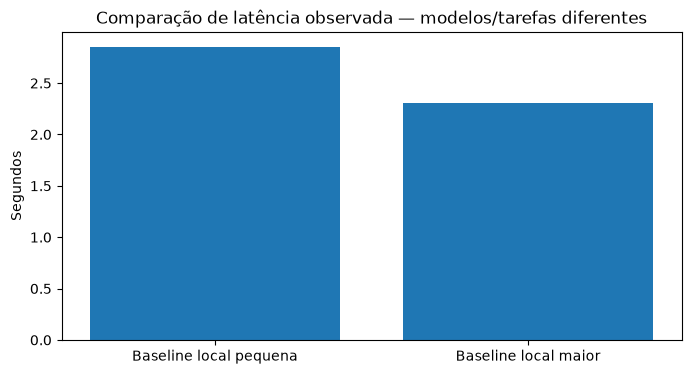

In [13]:
get_ipython().run_line_magic("matplotlib", "inline")
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 4))
plt.bar(["Baseline local pequena", "Baseline local maior"], [tempo_llm, tempo_lrm])
plt.ylabel("Segundos")
plt.title("Comparação de latência observada — modelos/tarefas diferentes")
plt.show()
